# **1. За допомогою скрипта Python підключаємось до бази даних в Google BigQuery (DA dataset)**

In [1]:
!pip install --upgrade google-cloud-bigquery

In [2]:
from google.colab import auth
from google.cloud import bigquery
from scipy.stats import pearsonr, shapiro, mannwhitneyu, f_oneway
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
auth.authenticate_user()

In [4]:
client = bigquery.Client(project="796019654077")

# **2. На основі таблиць, наявних у базі даних, напишемо запит у Python щоб створити датасет**

In [5]:
query = """
SELECT
  s.date AS date,
  s.ga_session_id AS session_id,
  sp.continent AS continent,
  sp.country AS country,
  sp.device AS device,
  sp.browser AS browser,
  sp.mobile_model_name AS device_model_name,
  sp.operating_system AS operating_system,
  sp.language AS browser_language,
  sp.channel AS traffic_source_information,
  acc.is_verified AS account_verified,
  acc.is_unsubscribed AS account_unsubscribed,
  p.category AS product_category,
  p.name AS product_name,
  p.price AS price,
  p.short_description AS short_product_description
FROM `DA.session` s
LEFT JOIN `DA.account_session` acs
      ON acs.ga_session_id = s.ga_session_id
LEFT JOIN `DA.account` acc
      ON acc.id = acs.account_id
LEFT JOIN `DA.session_params` sp
      ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `DA.order` o
      ON sp.ga_session_id = o.ga_session_id
LEFT JOIN `DA.product` p
      ON o.item_id = p.item_id
ORDER BY s.date
"""


query_job = client.query(query)
results = query_job.result()
df = results.to_dataframe(create_bqstorage_client=False)
df

,date,session_id,continent,country,device,browser,device_model_name,operating_system,browser_language,traffic_source_information,account_verified,account_unsubscribed,product_category,product_name,price,short_product_description
0,2020-11-01,65223751,Americas,United States,mobile,Chrome,<Other>,Web,en-us,Organic Search,<NA>,<NA>,None,None,NaN,None
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,Organic Search,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,Direct,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,Direct,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,Direct,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349540,2021-01-31,5756982967,Europe,Ukraine,desktop,Firefox,Firefox,Windows,en-us,Social Search,<NA>,<NA>,None,None,NaN,None
349541,2021-01-31,464560636,Americas,United States,desktop,Edge,Edge,Web,en-us,Organic Search,<NA>,<NA>,None,None,NaN,None
349542,2021-01-31,6336117447,Americas,United States,desktop,Chrome,Chrome,Web,en-us,Direct,<NA>,<NA>,None,None,NaN,None
349543,2021-01-31,4958826563,Asia,India,mobile,Safari,iPhone,iOS,de,Undefined,<NA>,<NA>,None,None,NaN,None


# **3. Робимо короткий опис отриманого датасету**

In [5]:
import io


df.columns = ['date', 'session_id', 'continent', 'country', 'device', 'browser', 'device_model_name', 'operating_system', 'browser_language', 'traffic_source_information', 'account_verified', 'account_unsubscribed', 'product_category', 'product_name', 'price', 'short_product_description']
df['date'] = pd.to_datetime(df['date'])

total_columns = df.shape[1]
print(f"1. Загальна кількість колонок: {total_columns}\n")


numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
print(f"2. Кількість числових колонок: {len(numeric_columns)}")
if numeric_columns:
    print(f"   -  Назви: {numeric_columns}\n")

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"3. Кількість категоріальних колонок: {len(categorical_columns)}")
if categorical_columns:
    print(f"   -  Назви: {categorical_columns}\n")

datetime_columns = df.select_dtypes(include=['datetime']).columns.tolist()
print(f"4. Кількість колонок типу datetime: {len(datetime_columns)}")
if datetime_columns:
    print(f"   -  Назви: {datetime_columns}\n")

unique_sessions = df['session_id'].nunique()
print(f"5. Кількість унікальних сесій: {unique_sessions}\n")

date_range_start = df['date'].min().strftime('%Y-%m-%d')
date_range_end = df['date'].max().strftime('%Y-%m-%d')
print(f"6. Період часу: з {date_range_start} до {date_range_end}\n")

missing_placeholders = ['(not set)', 'None', '<NA>', '(data deleted)', 'NaN', 'NA']
df_with_na = df.replace(missing_placeholders, pd.NA)
missing_values = df_with_na.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("7. Пропущені значення:")
if not missing_values.empty:
    print("   Так, є пропущені значення. Розподіл по колонках:")
    print(missing_values.to_string())
else:
    print("   Пропущених значень не знайдено.")

1. Загальна кількість колонок: 16

2. Кількість числових колонок: 4
   -  Назви: ['session_id', 'account_verified', 'account_unsubscribed', 'price']

3. Кількість категоріальних колонок: 11
   -  Назви: ['continent', 'country', 'device', 'browser', 'device_model_name', 'operating_system', 'browser_language', 'traffic_source_information', 'product_category', 'product_name', 'short_product_description']

4. Кількість колонок типу datetime: 1
   -  Назви: ['date']

5. Кількість унікальних сесій: 349545

6. Період часу: з 2020-11-01 до 2021-01-31

7. Пропущені значення:
   Так, є пропущені значення. Розподіл по колонках:
account_unsubscribed         321600
account_verified             321600
price                        316007
product_name                 316007
product_category             316007
short_product_description    316007
browser_language             114266
country                        2808
continent                       795


**Опис датасету**

*Загальна кількість колонок* - **16**

*Кількість колонок числового типу (та які саме):*
* session_id
* account_unsubscribed
* account_verified
* price

*Кількість колонок категоріального типу (та які саме):*
* continent
* country
* device
* browser
* device_model_name
* operating_system
* browser_language
* traffic_source_information
* product_category
* product_name
* short_product_description

*Кількість колонок типу datetime:*
* date

*Кількість унікальних сесій* - **349545**

*Який період часу розглядається* - **з 2020-11-01 до 2021-01-31**

*Чи є пропущені значення* - **Так, є пропущені**

*В яких колонках більше пропущених значень, яка причина?:*

Колонки account_unsubscribed, account_verified (321600 записів у кожній)

**Причина:** Ці колонки заповнені лише для зареєстрованих користувачів, які становлять невелику частку всіх сесій

# **4. Даємо відповіді на питання**


## 4.1 На яких континентах (топ-3) та в яких країнах (топ-5) наша компанія має найбільші продажі? найбільшу кількість замовлень?

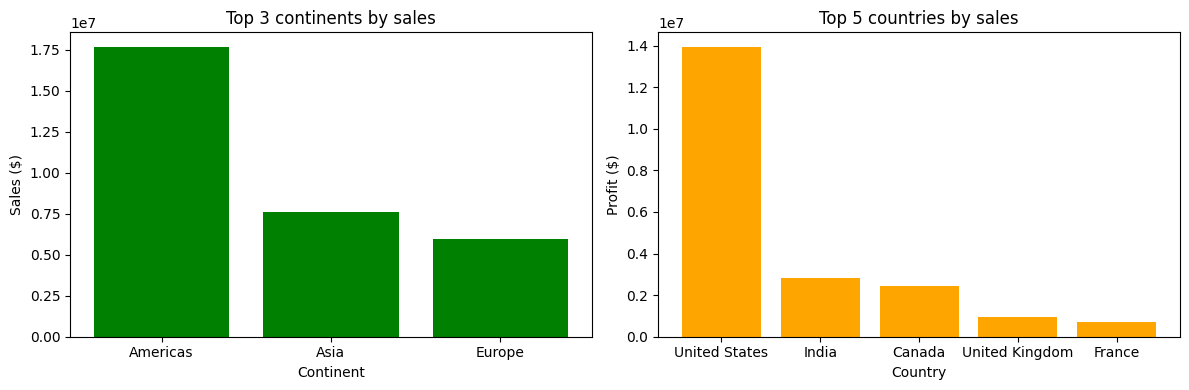

In [7]:
continents = df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3)
countries = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(continents.index, continents.values, color="green")
ax[0].set_title("Top 3 continents by sales")
ax[0].set_xlabel("Continent")
ax[0].set_ylabel("Sales ($)")

ax[1].bar(countries.index, countries.values,  color="orange")
ax[1].set_title("Top 5 countries by sales")
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Profit ($)")

plt.tight_layout()
plt.show()

**Найбільші продажі**

**Континенти:** Північна та Південна Америки, Азія та Європа

**Країни:** США, Індія, Канада, Сполучене Королівсто, Франція

## 4.2 Топ-10 категорій товарів за загальною сумою продажів

In [27]:
top_10_categories = df.groupby('product_category')['price'].sum().sort_values(ascending=False).sort_values(ascending=False).head(10)
top_10_categories.head(10)

,price
product_category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5
Outdoor furniture,2142222.2
Tables & desks,1790307.5
Chests of drawers & drawer units,906562.5
Bar furniture,735503.0


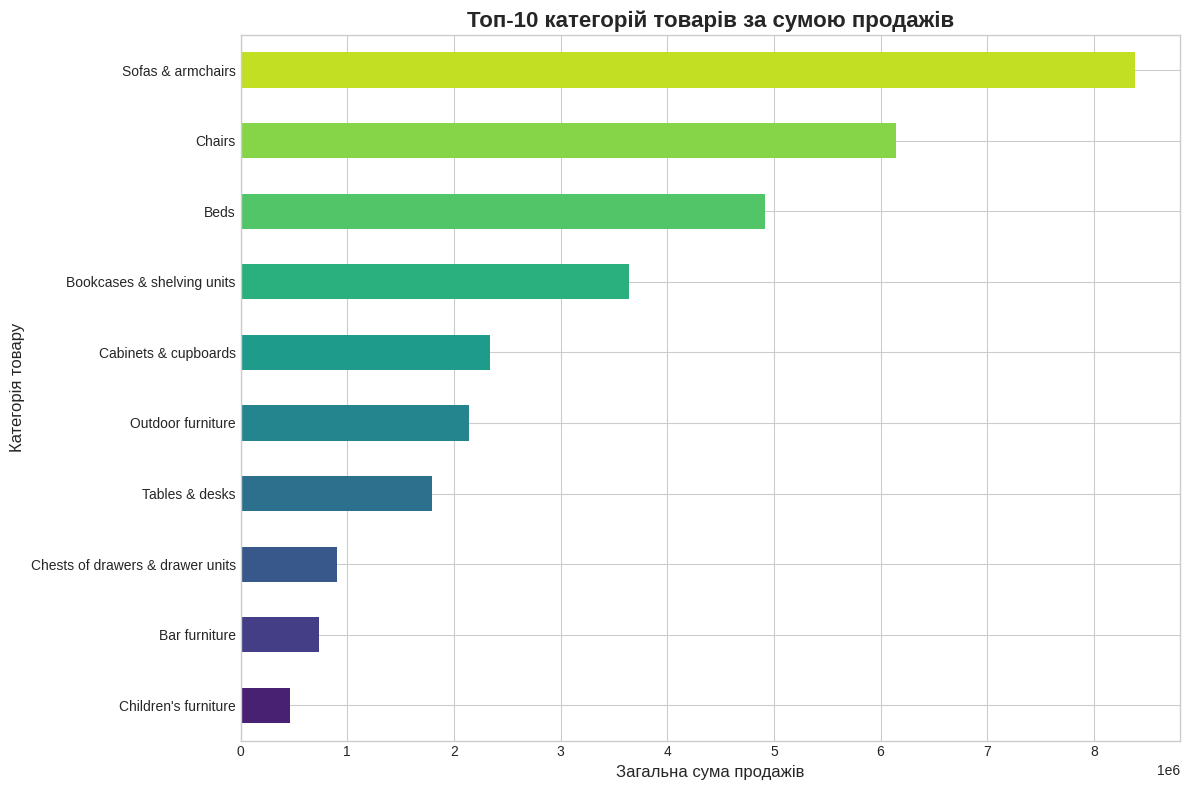

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))
top_10_categories.sort_values(ascending=True).plot(kind='barh', color=sns.color_palette("viridis", 10))

plt.xlabel('Загальна сума продажів', fontsize=12)
plt.ylabel('Категорія товару', fontsize=12)
plt.title('Топ-10 категорій товарів за сумою продажів', fontsize=16, weight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

In [17]:
top_categories = df.groupby('product_category')['price'].sum().head(10)
top_usa = df[(df['country'] == 'United States') & (df['product_category'].notnull())]
top_usa = top_usa.groupby('product_category')['price'].sum().head(10)

/tmp/ipykernel_6416/1836408746.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_6416/1836408746.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')


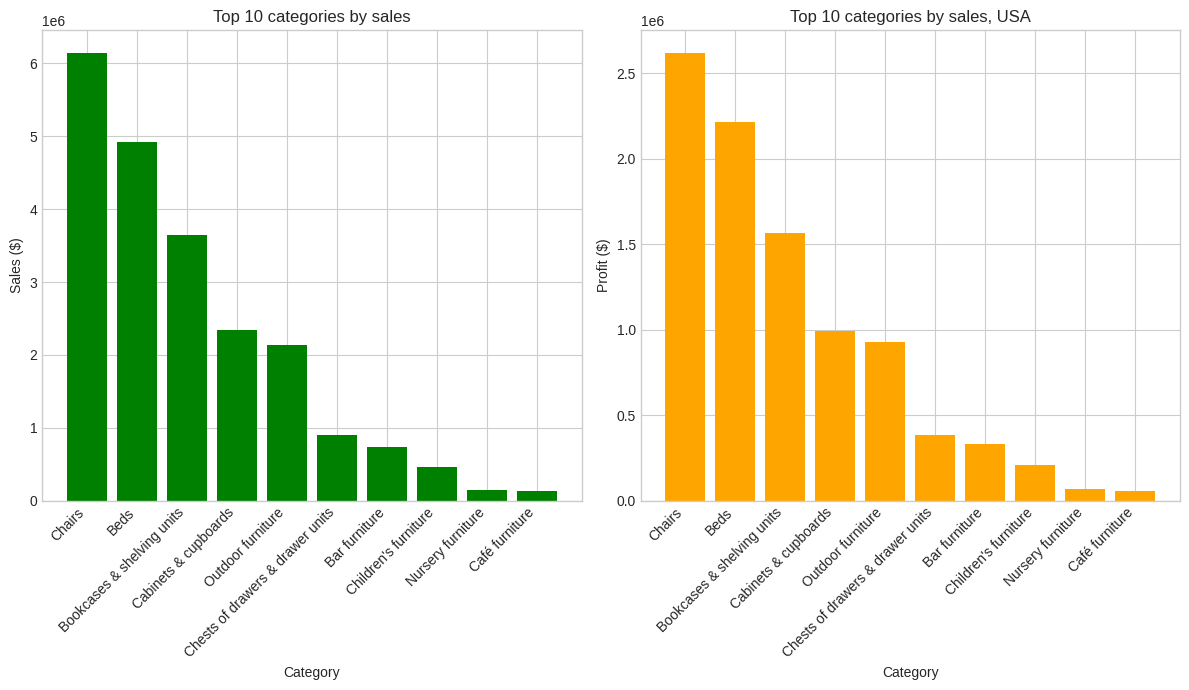

In [32]:
top_categories = top_categories.sort_values(ascending=False)
top_usa = top_usa.sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 7))

ax[0].bar(top_categories.index, top_categories.values, color="green")
ax[0].set_title("Top 10 categories by sales")
x_tickers = ax[0].get_xticks()
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha='right')
ax[0].set_xlabel("Category")
ax[0].set_ylabel("Sales ($)")

ax[1].bar(top_usa.index, top_usa.values,  color="orange")
ax[1].set_title("Top 10 categories by sales, USA")
ax[1].set_xlabel("Category")
x_tickers = ax[1].get_xticks()
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')
ax[1].set_ylabel("Profit ($)")

plt.tight_layout()
plt.show()

## 4.3 Топ-10 категорій товарів у країні з найбільшими продажами

In [29]:
df_usa = df[df['country'] == 'United States']
print(f"Загальна кількість сесій: {len(df)}")
print(f"Кількість сесій у США: {len(df_usa)}")

Загальна кількість сесій: 349545
Кількість сесій у США: 153470


In [30]:
top_10_sales_usa = df_usa.groupby("product_category")["price"].sum().sort_values(ascending = False).head(10)
print("Топ-10 категорії за сумою продажів в розрізі США:")
print(top_10_sales_usa)

Топ-10 категорії за сумою продажів в розрізі США:
product_category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


## 4.4 Продажі у розрізі типів та моделей девайсів (у % від загальних продажів)

In [33]:
sales_grouped_device = df.groupby("device")["price"].sum()
total_sales = df['price'].sum()
device_sales_percent = (sales_grouped_device / total_sales) * 100
device_sales_percent = device_sales_percent.sort_values(ascending=False)

print("Продажі за типом девайсу (у % від загальних):")
print(device_sales_percent.round(2))

Продажі за типом девайсу (у % від загальних):
device
desktop    59.00
mobile     38.73
tablet      2.26
Name: price, dtype: float64


/tmp/ipykernel_6416/3865682100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_sales_percent.values, y=device_sales_percent.index, palette="viridis")


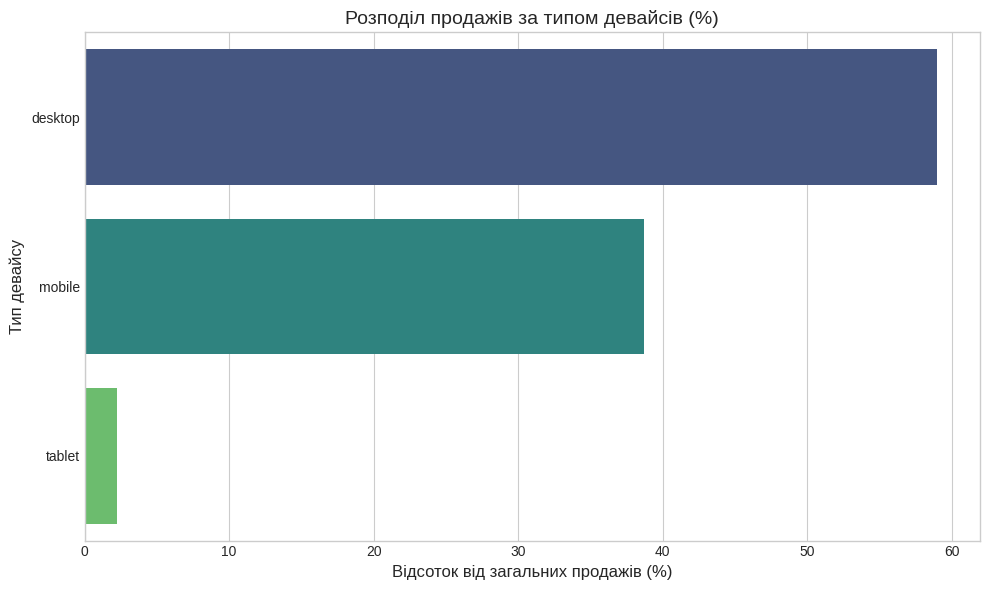

In [43]:
plt.figure(figsize=(10, 6))

sns.barplot(x=device_sales_percent.values, y=device_sales_percent.index, palette="viridis")

plt.title('Розподіл продажів за типом девайсів (%)', fontsize=14)
plt.xlabel('Відсоток від загальних продажів (%)', fontsize=12)
plt.ylabel('Тип девайсу', fontsize=12)

plt.tight_layout()

In [44]:
browsers = ['Chrome', 'Safari', 'Firefox', 'Edge', 'Opera', '<Other>']
df_devices = df[~df['device_model_name'].isin(browsers)]
sales_grouped_device_model = df_devices.groupby("device_model_name")["price"].sum()
total_sales_devices_only = df_devices['price'].sum()
device_model_sales_percent = (sales_grouped_device_model / total_sales_devices_only) * 100
device_model_sales_percent = device_model_sales_percent.sort_values(ascending=False)

print("Продажі моделей девайсів (у % від відфільтрованих):")
print(device_model_sales_percent.round(2))

Продажі моделей девайсів (у % від відфільтрованих):
device_model_name
iPhone        71.92
ChromeBook    20.50
iPad           5.03
Pixel 4 XL     1.32
Pixel 3        1.22
Name: price, dtype: float64


/tmp/ipykernel_6416/3897690648.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=device_model_sales_percent.values, y=device_model_sales_percent.index, palette="viridis")


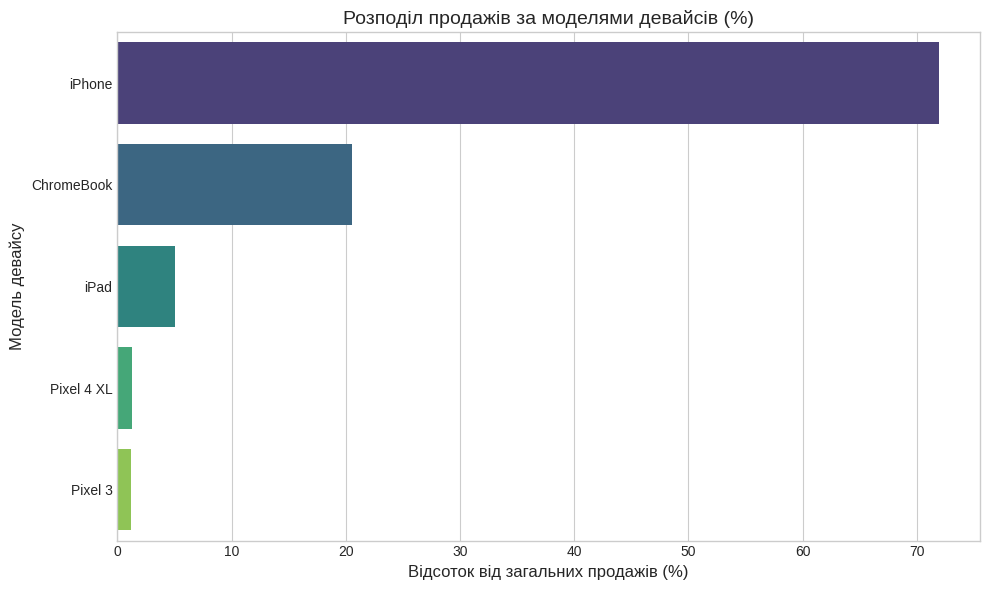

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(x=device_model_sales_percent.values, y=device_model_sales_percent.index, palette="viridis")

plt.title('Розподіл продажів за моделями девайсів (%)', fontsize=14)
plt.xlabel('Відсоток від загальних продажів (%)', fontsize=12)
plt.ylabel('Модель девайсу', fontsize=12)

plt.tight_layout()

## 4.5 Продажі за джерелами трафіку (у % від загальних продажів)

In [46]:
sales_traffic = df.groupby("traffic_source_information")["price"].sum()
total_sales_traffic = df['price'].sum()
traffic_sales_percent = (sales_traffic / total_sales_traffic) * 100
traffic_sales_percent = traffic_sales_percent.sort_values(ascending=False)

print("Продажі за джерелом трафіку (%):")
print(traffic_sales_percent.round(2))

Продажі за джерелом трафіку (%):
traffic_source_information
Organic Search    35.76
Paid Search       26.62
Direct            23.44
Social Search      7.92
Undefined          6.26
Name: price, dtype: float64


/tmp/ipykernel_6416/6646505.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=traffic_sales_percent.values, y=traffic_sales_percent.index, palette="viridis")


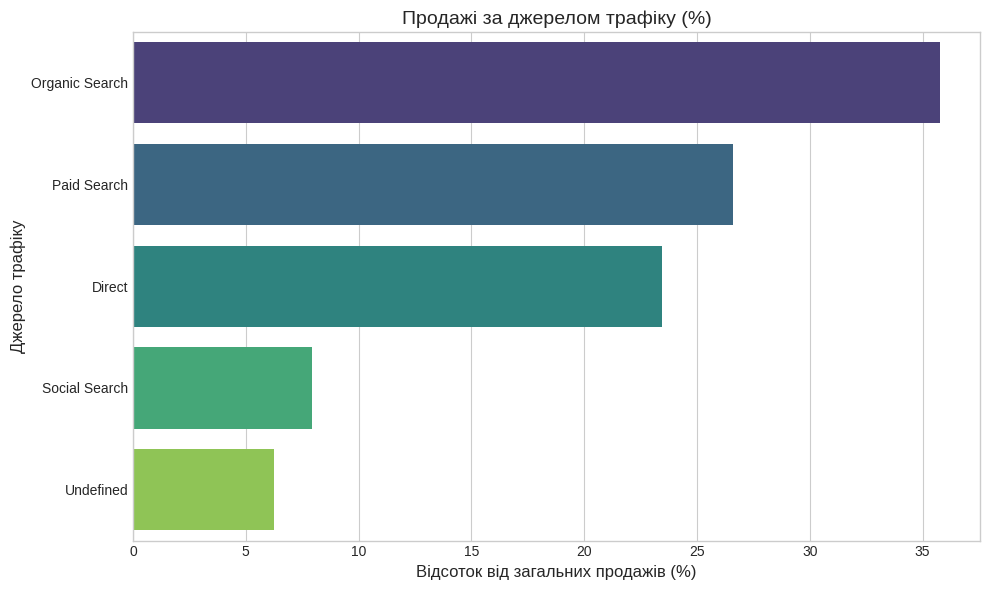

In [49]:
plt.figure(figsize=(10, 6))

sns.barplot(x=traffic_sales_percent.values, y=traffic_sales_percent.index, palette="viridis")
plt.title('Продажі за джерелом трафіку (%)', fontsize=14)
plt.xlabel('Відсоток від загальних продажів (%)', fontsize=12)
plt.ylabel('Джерело трафіку', fontsize=12)

plt.tight_layout()

## 4.6 Відсоток зареєстрованих користувачів, що підтвердили свою електронну адресу

In [50]:
df_registered = df[df['account_verified'].notna()]
percent_verified = df_registered['account_verified'].mean()

print(f"Відсоток підтверджених: {percent_verified * 100:.1f}%")

Відсоток підтверджених: 71.7%


## 4.7 Відсоток зареєстрованих користувачів, що відписалися від розсилки

In [51]:
percent_unsubscribed = df_registered['account_unsubscribed'].mean()

print(f"Відсоток тих, хто відписався: {percent_unsubscribed * 100:.1f}%")

Відсоток тих, хто відписався: 16.9%


## 4.8 Чи відрізняється поведінка (у плані продажів) тих, хто відписався від розсилки та тих, хто досі підписаний?

In [55]:
df_unsubscribed = df_registered[df_registered['account_unsubscribed'] == 1]
df_subscribed = df_registered[df_registered['account_unsubscribed'] == 0]

print("-//- Статистика для тих, хто відписався -//-")
print(df_unsubscribed['price'].describe())

print("\n-//- Статистика для тих, хто досі підписаний -//-")
print(df_subscribed['price'].describe())

-//- Статистика для тих, хто відписався -//-
count     447.000000
mean      965.820134
std      1298.176986
min         3.000000
25%       175.000000
50%       450.000000
75%      1297.500000
max      8900.000000
Name: price, dtype: float64

-//- Статистика для тих, хто досі підписаний -//-
count    2334.000000
mean      921.506812
std      1323.918182
min         3.000000
25%       149.000000
50%       395.000000
75%      1100.000000
max      8900.000000
Name: price, dtype: float64


Користувачі, які залишилися підписаними, зробили набагато більше покупок (2334), ніж ті, хто відписався (447).

## 4.9 В яких країнах найбільше зареєстрованих користувачів

In [7]:
df_registered = df[df['account_verified'].notna()]
grouped_country_registered = df_registered.groupby("country")["session_id"].count().sort_values(ascending=False).head(10)

print("Топ-10 країн за кількістю зареєстрованих користувачів:")
print(grouped_country_registered)

Топ-10 країн за кількістю зареєстрованих користувачів:
country
United States     12384
India              2687
Canada             2067
United Kingdom      859
France              553
Spain               536
Taiwan              500
China               490
Germany             490
Italy               386
Name: session_id, dtype: Int64


/tmp/ipykernel_3407/749566315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grouped_country_registered.values, y=grouped_country_registered.index, palette="viridis")


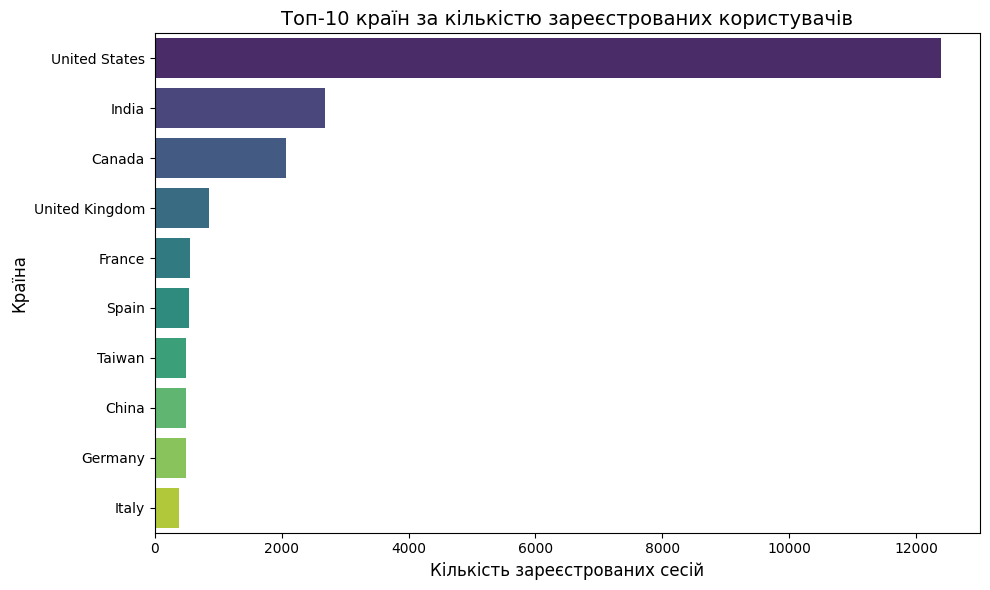

In [8]:
plt.figure(figsize=(10, 6))

sns.barplot(x=grouped_country_registered.values, y=grouped_country_registered.index, palette="viridis")
plt.title('Топ-10 країн за кількістю зареєстрованих користувачів', fontsize=14)
plt.xlabel('Кількість зареєстрованих сесій', fontsize=12)
plt.ylabel('Країна', fontsize=12)

plt.tight_layout()

# **5. Аналіз динаміки продажів**

## 5.1 Загальні продажі за кожну дату (візуалізація загальної динаміки продажів)

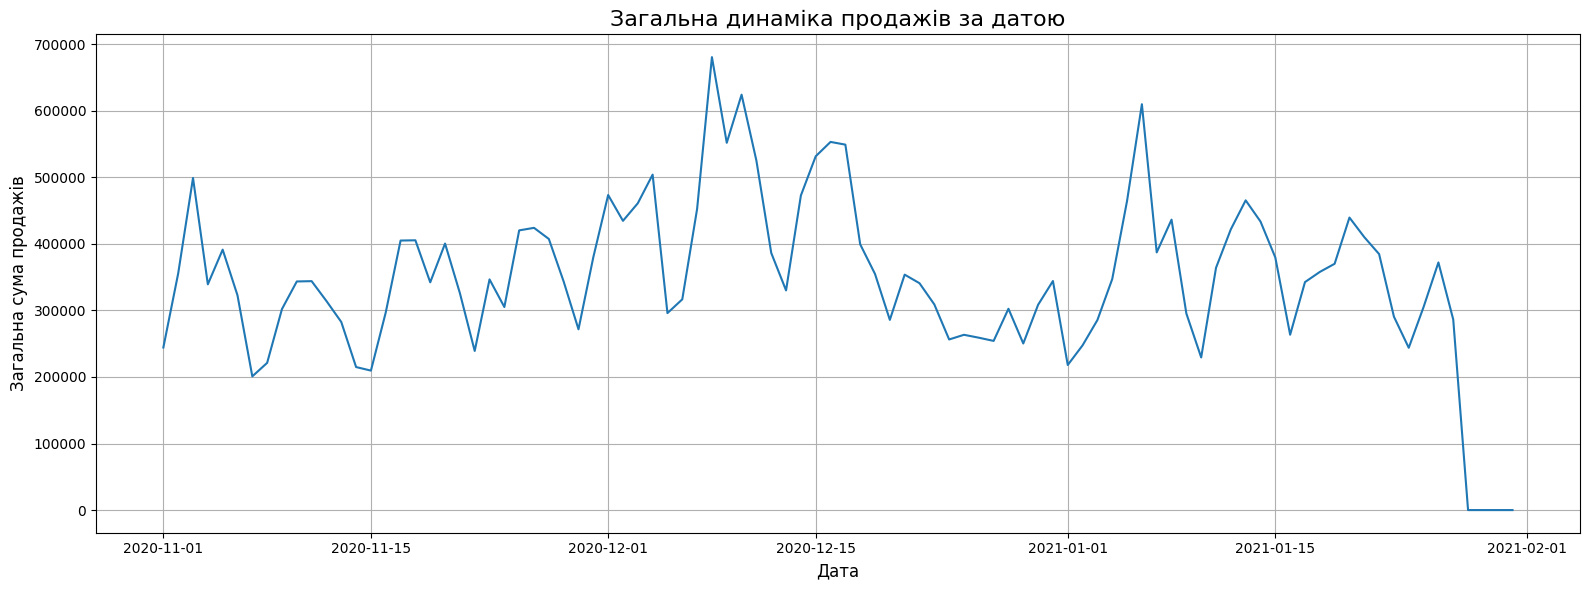

In [14]:
grouped_date_sum = df.groupby('date')['price'].sum()

plt.figure(figsize=(16, 6))
sns.lineplot(x=grouped_date_sum.index, y=grouped_date_sum.values)

plt.title('Загальна динаміка продажів за датою', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальна сума продажів', fontsize=12)
plt.grid(True)
plt.tight_layout()

На графіку бачимо два великих піки продажів:
* Перший - Приблизно, Pearl Harbor Remembrance Day (07.12.2020)
* Другий - Початок Нового Року (2021)

Сезонність є — але слабка і короткострокова. Є різкі сплески (початок грудня початок січня)
Це більше схоже на святковий період Christmas і, можливо, маркетингові акції після Нового Року

## 5.2 Аналіз динаміки продажів в Америці, Азії та Європі

In [15]:
df_continent = df[df['continent'].isin(['Americas', 'Asia', 'Europe'])]
group_continent = df_continent.groupby(['date', 'continent'])['price'].sum()

sales_by_continent_df = group_continent.reset_index()

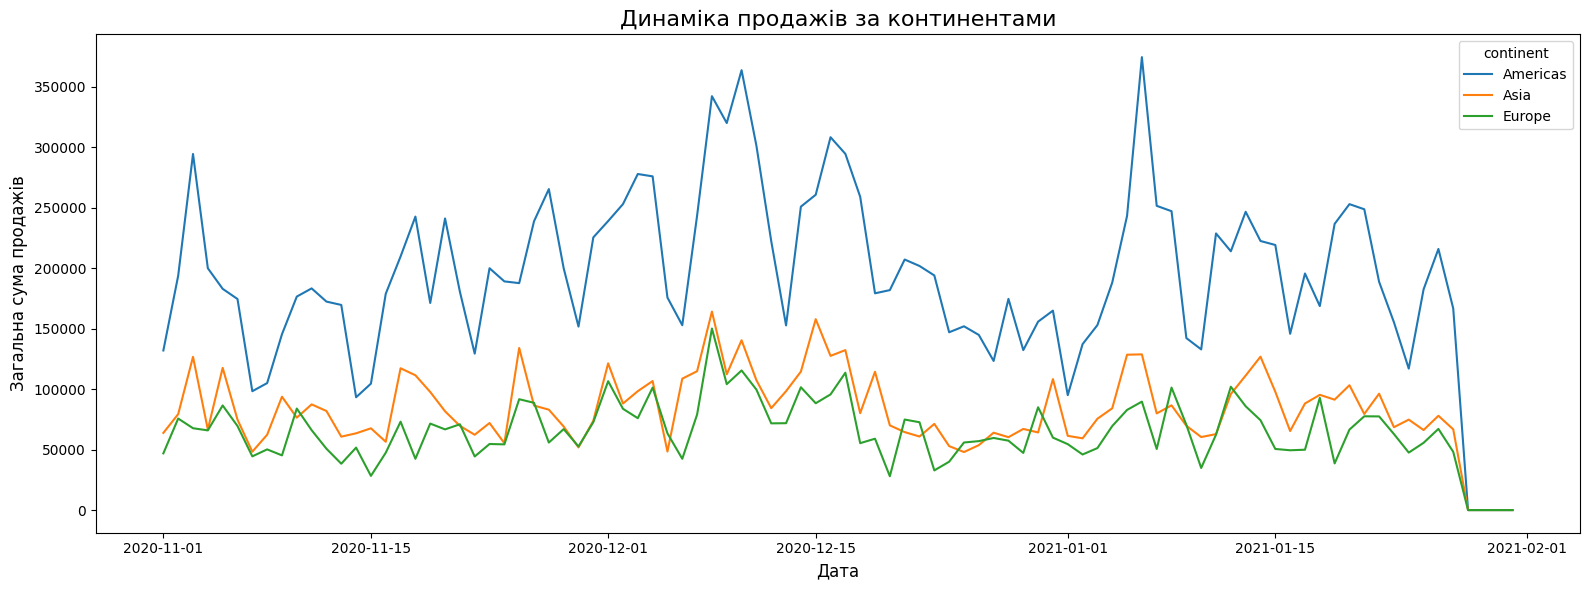

In [24]:
plt.figure(figsize=(16, 6))

sns.lineplot(data=sales_by_continent_df, x='date', y='price', hue='continent')

plt.title('Динаміка продажів за континентами', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальна сума продажів', fontsize=12)
plt.tight_layout()

## 5.3 Аналіз динаміки продажів у розрізі каналів трафіку

In [25]:
group_traffic = df.groupby(['date', 'traffic_source_information'])['price'].sum()
sales_by_traffic_df = group_traffic.reset_index()

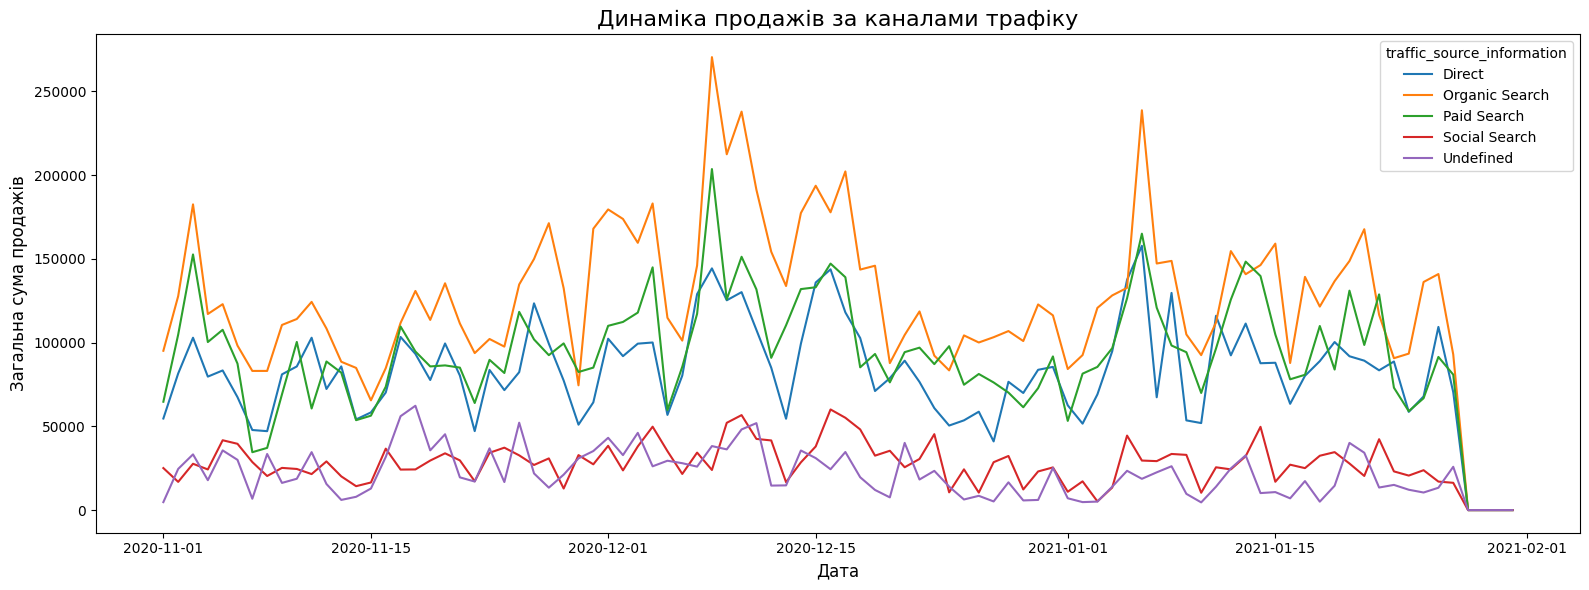

In [26]:
plt.figure(figsize=(16, 6))

sns.lineplot(data=sales_by_traffic_df, x='date', y='price', hue='traffic_source_information')

plt.title('Динаміка продажів за каналами трафіку', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальна сума продажів', fontsize=12)
plt.tight_layout()

## 5.4 Аналіз динаміки продажів у розрізі типів девайсів

In [27]:
group_device = df.groupby(['date', 'device'])['price'].sum()
sales_by_device_df = group_device.reset_index()

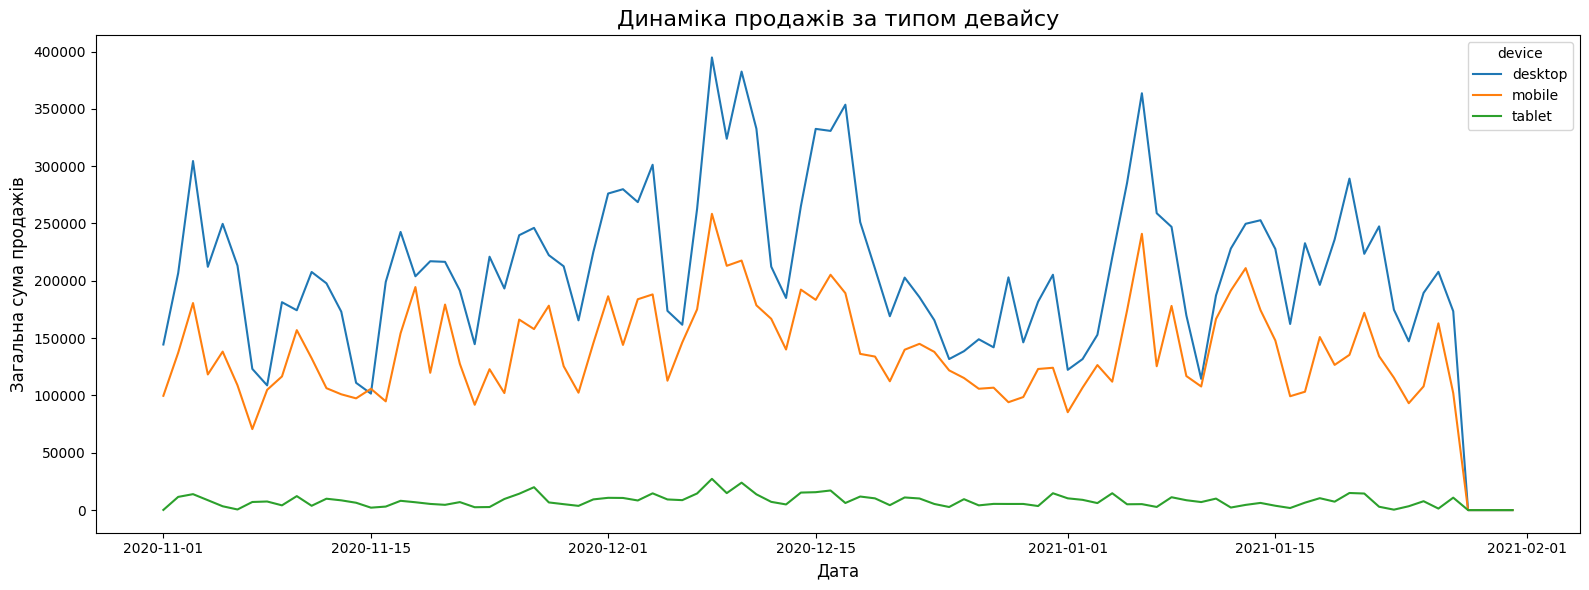

In [29]:
plt.figure(figsize=(16, 6))

sns.lineplot(data=sales_by_device_df, x='date', y='price', hue='device')

plt.title('Динаміка продажів за типом девайсу', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загальна сума продажів', fontsize=12)
plt.tight_layout()

Висновки з отриманих візуалізацій:
* Є чіткі піки продажів - початок грудня і початок січня
* Усі континенти мають однакові пікив ті самі дати (глобальні свята і акції)
* Organic Search - головне джерело продажів
* Користувачі купують переважно з комп'ютера

# **6. Зведені таблиці**

## 6.1 Таблиця, яка показує кількість сесій у розрізі каналів трафіку та типів девайсів

In [31]:
pivot_table_sessions = pd.pivot_table(df, values='session_id', index='traffic_source_information', columns='device', aggfunc='count')

print("Зведена таблиця: Сесії у розрізі каналів трафіку та типів девайсів")
print(pivot_table_sessions)

Зведена таблиця: Сесії у розрізі каналів трафіку та типів девайсів
device                      desktop  mobile  tablet
traffic_source_information                         
Direct                        47825   31745    1812
Organic Search                72622   49014    2789
Paid Search                   55167   37034    2140
Social Search                 16288   10988     638
Undefined                     12527    8486     470


## 6.2 Таблиця, яка показує загальні продажі за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн)


In [34]:
top_5_countries_list = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5).index
top_10_categories_list = df.groupby('product_category')['price'].sum().sort_values(ascending=False).head(10).index

condition_country = df['country'].isin(top_5_countries_list)
condition_category = df['product_category'].isin(top_10_categories_list)

df_top_sales = df[condition_country & condition_category]

pivot_table = pd.pivot_table(df_top_sales, values='price', index='product_category', columns='country', aggfunc='sum')
print(pivot_table.to_string())

country                             Canada    France     India  United Kingdom  United States
product_category                                                                             
Bar furniture                      51724.0   11199.0   57657.0         22103.0       330805.0
Beds                              354772.0  116414.0  358319.5        133816.0      2213058.0
Bookcases & shelving units        278981.9   73830.0  364507.4        113987.6      1567606.9
Cabinets & cupboards              181802.0   59101.5  191888.0         71684.5       994545.5
Chairs                            417740.8  134029.4  544309.2        188519.4      2619773.8
Chests of drawers & drawer units   71952.0   21544.5   73111.0         36784.0       382388.0
Children's furniture               30264.0   14258.0   39177.0         13348.0       207575.0
Outdoor furniture                 185322.8   40486.4  162289.4         57002.4       929245.2
Sofas & armchairs                 692427.5  187735.0  788430

## 6.3 Таблиця, яка показує середній чек  у розрізі континентів та типів девайсів

In [36]:
browsers = ['Chrome', 'Safari', 'Firefox', 'Edge', 'Opera']
df_devices = df[~df['device_model_name'].isin(browsers)]

pivot_table = pd.pivot_table(df_devices, values='price', index='device_model_name', columns='continent', aggfunc='mean')

print("Зведена таблиця: Середній чек у розрізі континентів та девайсів")
print(pivot_table.to_string())

Зведена таблиця: Середній чек у розрізі континентів та девайсів
continent            (not set)       Africa     Americas         Asia       Europe      Oceania
device_model_name                                                                              
<Other>            1046.900000  1090.268116   964.410840   994.627377   897.932610   960.241935
ChromeBook          882.200000  1508.875000   976.799809   940.603935  1003.393429   808.732143
Pixel 3                    NaN          NaN   945.267273  1421.000000   741.340000  2196.000000
Pixel 4 XL                 NaN          NaN  1038.135714  1073.414815   831.800000          NaN
iPad                 70.000000   414.200000  1001.534800   949.622642  1007.747191  1196.000000
iPhone             1124.166667   776.728750   914.384878   979.186613   989.351339   776.939655


## 6.4 Таблиця, яка показує загальну суму продажів для кожної комбінації каналу трафіку та типу девайсу

In [38]:
pivot_table = pd.pivot_table(df_devices, values='price', index='device', columns='traffic_source_information', aggfunc='sum')

print("Зведена таблиця: Cума продажів для кожної комбінації каналу крафіку та типу девайсу")
print(pivot_table.to_string())

Зведена таблиця: Cума продажів для кожної комбінації каналу крафіку та типу девайсу
traffic_source_information     Direct  Organic Search  Paid Search  Social Search  Undefined
device                                                                                      
desktop                      570692.3        803466.0     635232.1       193635.8   153077.6
mobile                      2874772.9       4408825.1    3329687.6      1006707.3   763292.9
tablet                       146996.1        230168.7     204039.0        78013.6    64248.9


# **7. Статистичний аналіз взаємозв’язків**

## 7.1 Кількість сесій та загальні продажі за кожну дату. Відповідний коефіцієнт кореляці

In [44]:
aggregations = {'price': 'sum','session_id': 'count'}
daily_metrics = df.groupby('date').agg(aggregations)
daily_metrics.rename(columns={'price': 'total_sales', 'session_id': 'session_count'}, inplace=True)
print(daily_metrics.head())

            total_sales  session_count
date                                  
2020-11-01     244292.5           2576
2020-11-02     355506.8           3599
2020-11-03     498979.6           5173
2020-11-04     339187.1           4184
2020-11-05     391276.6           3743


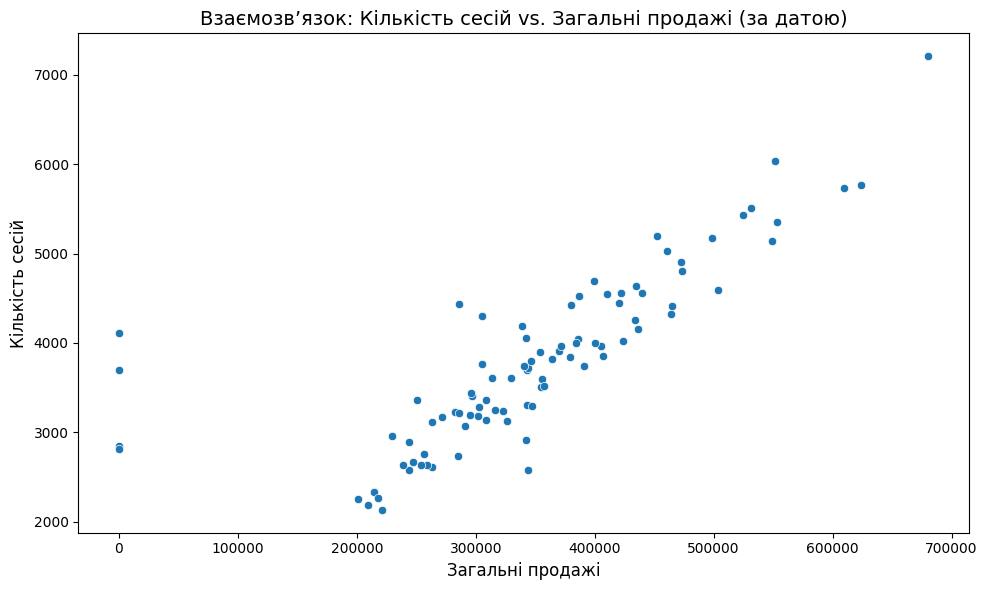

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=daily_metrics, x='total_sales', y='session_count')

plt.title('Взаємозв’язок: Кількість сесій vs. Загальні продажі (за датою)', fontsize=14)
plt.xlabel('Загальні продажі', fontsize=12)
plt.ylabel('Кількість сесій', fontsize=12)

plt.tight_layout()

In [47]:
r_value, p_value = pearsonr(daily_metrics['total_sales'], daily_metrics['session_count'])

print(f"Коефіцієнт кореляції (r): {r_value}")
print(f"P-value: {p_value}")

Коефіцієнт кореляції (r): 0.7910809164540891
P-value: 6.483532312080735e-21


Діаграмма розсіювання показала, що показники корелюють.
Від кількості сессій залежить сумма продажів - сильна позитивна кореляція.

Рохрахунок коефіціенту кореляції Пірсона:

* Коефіціент кореляції: 0.791
* P-value: 6.483532312080735e-21

Висновок:

Значення +0.791 — це сильна позитивна кореляція.
P-value набагато менше за стандартний поріг 0.05, що є статистично значущим.

## 7.2 Чи корелюють між собою продажі на різних континентах? Візьми топ-3 континенти

In [50]:
grouped_continent_totals = df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3)
top_3_list = grouped_continent_totals.index
print("Топ-3 континенти:", top_3_list.to_list())

Топ-3 континенти: ['Americas', 'Asia', 'Europe']


In [57]:
df_top_continents = df[df['continent'].isin(top_3_list)]

daily_sales_by_continent = pd.pivot_table(df_top_continents, values='price', index='date', columns='continent', aggfunc='sum')
print("Підготовлена таблиця для кореляції (перші 5 рядків):")
print(daily_sales_by_continent.head())

r_av_as, p_av_as = pearsonr(daily_sales_by_continent['Americas'], daily_sales_by_continent['Asia'])
print(f"\n-//- Кореляція: Americas vs. Asia -//-")
print(f"Коефіцієнт (r): {r_av_as:.4f}, P-value: {p_av_as}")
if p_av_as < 0.05:
    print("Результат є статистично значущим (p < 0.05).")

r_av_eu, p_av_eu = pearsonr(daily_sales_by_continent['Americas'], daily_sales_by_continent['Europe'])
print(f"\n-//- Кореляція: Americas vs. Europe -//-")
print(f"Коефіцієнт (r): {r_av_eu:.4f}, P-value: {p_av_eu}")
if p_av_eu < 0.05:
    print("Результат є статистично значущим (p < 0.05).")

r_as_eu, p_as_eu = pearsonr(daily_sales_by_continent['Asia'], daily_sales_by_continent['Europe'])
print(f"\n-//- Кореляція: Asia vs. Europe -//-")
print(f"Коефіцієнт (r): {r_as_eu:.4f}, P-value: {p_as_eu}")
if p_as_eu < 0.05:
    print("Результат є статистично значущим (p < 0.05).")

Підготовлена таблиця для кореляції (перші 5 рядків):
continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0

-//- Кореляція: Americas vs. Asia -//-
Коефіцієнт (r): 0.7920, P-value: 5.409189396197475e-21
Результат є статистично значущим (p < 0.05).

-//- Кореляція: Americas vs. Europe -//-
Коефіцієнт (r): 0.7706, P-value: 2.6714492240629956e-19
Результат є статистично значущим (p < 0.05).

-//- Кореляція: Asia vs. Europe -//-
Коефіцієнт (r): 0.7684, P-value: 3.8649460090531196e-19
Результат є статистично значущим (p < 0.05).


## 7.3 Чи корелюють між собою продажі за різними каналами трафіку?

In [67]:
sales_by_traffic = pd.pivot_table(df, values='price', index='date', columns='traffic_source_information', aggfunc='sum')
sales_by_traffic = sales_by_traffic.fillna(0)
channel_list = sales_by_traffic.columns

print(sales_by_traffic.head().to_string())

print("\n-//- Кореляційний аналіз каналів трафіку -//-")

results = []

for i in range(len(channel_list)):
    for j in range(i + 1, len(channel_list)):
        ch1 = channel_list[i]
        ch2 = channel_list[j]

        r, p = pearsonr(sales_by_traffic[ch1], sales_by_traffic[ch2])

        results.append([ch1, ch2, r, p])

results_df = pd.DataFrame(results, columns=['channel_1', 'channel_2', 'r', 'p'])
results_df

traffic_source_information    Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                                       
2020-11-01                   54669.5         95112.0      64688.0        25078.0     4745.0
2020-11-02                   81561.5        127746.5     104780.8        16843.0    24575.0
2020-11-03                  102909.5        182521.9     152641.3        27652.5    33254.4
2020-11-04                   79683.6        117067.1     100332.0        24257.4    17847.0
2020-11-05                   83367.6        122938.4     107648.0        41693.2    35629.4

-//- Кореляційний аналіз каналів трафіку -//-


,channel_1,channel_2,r,p
0,Direct,Organic Search,0.837833,2.190420e-25
1,Direct,Paid Search,0.814072,5.896435e-23
2,Direct,Social Search,0.604060,1.831889e-10
3,Direct,Undefined,0.517505,1.275436e-07
4,Organic Search,Paid Search,0.870086,2.142003e-29
5,Organic Search,Social Search,0.583117,1.066192e-09
6,Organic Search,Undefined,0.526068,7.228214e-08
7,Paid Search,Social Search,0.596428,3.532284e-10
8,Paid Search,Undefined,0.521961,9.509609e-08
9,Social Search,Undefined,0.455126,5.161928e-06


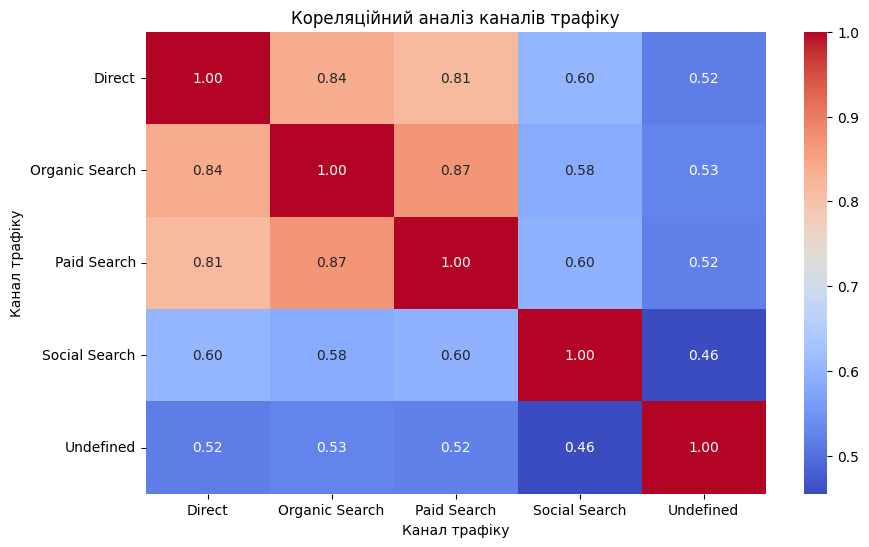

In [78]:
pivot_corr = sales_by_traffic.corr()

plt.figure(figsize=(10,6))
sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляційний аналіз каналів трафіку")
plt.xlabel('Канал трафіку', fontsize=10)
plt.ylabel('Канал трафіку', fontsize=10)
plt.show()

## 7.4 Чи корелюють між собою продажі за топ-5 категоріями товарів?

In [73]:
grouped_category_totals = df.groupby('product_category')['price'].sum().sort_values(ascending=False).head(5)
top_5_list = grouped_category_totals.index
print("Топ-5 категорій:", top_5_list.to_list())

df_top_category = df[df['product_category'].isin(top_5_list)]

daily_sales_by_categories = pd.pivot_table(df_top_category, values='price', index='date', columns='product_category', aggfunc='sum')
daily_sales_by_categories = daily_sales_by_categories.fillna(0)

print("\nПідготовлена таблиця для кореляції (перші 5 рядків):")
print(daily_sales_by_categories.head().to_string())

category_list = daily_sales_by_categories.columns

print("\n-//- Кореляційний аналіз Топ-5 категорій -//-")

results = []

for i in range(len(category_list)):
    for j in range(i + 1, len(category_list)):
        ctg1 = category_list[i]
        ctg2 = category_list[j]

        r, p = pearsonr(daily_sales_by_categories[ctg1], daily_sales_by_categories[ctg2])

        results.append([ctg1, ctg2, r, p])

results_df = pd.DataFrame(results, columns=['category_1', 'category_2', 'r', 'p'])
results_df

Топ-5 категорій: ['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards']

Підготовлена таблиця для кореляції (перші 5 рядків):
product_category     Beds  Bookcases & shelving units  Cabinets & cupboards   Chairs  Sofas & armchairs
date                                                                                                   
2020-11-01        14041.0                     36701.0               13591.5  46006.0            75216.0
2020-11-02        79683.5                     40979.0               21623.0  58834.0            79977.5
2020-11-03        66219.5                     64360.1               33555.5  61204.0           175594.0
2020-11-04        48939.0                     35719.8               19266.0  44113.0            86861.5
2020-11-05        23449.0                     40998.8               29235.0  90388.4           137288.0

-//- Кореляційний аналіз Топ-5 категорій -//-


,category_1,category_2,r,p
0,Beds,Bookcases & shelving units,0.592913,1.154998e-09
1,Beds,Cabinets & cupboards,0.514609,2.910930e-07
2,Beds,Chairs,0.554500,2.079183e-08
3,Beds,Sofas & armchairs,0.535378,7.687333e-08
4,Bookcases & shelving units,Cabinets & cupboards,0.539428,5.867225e-08
5,Bookcases & shelving units,Chairs,0.637090,2.504550e-11
6,Bookcases & shelving units,Sofas & armchairs,0.666194,1.406972e-12
7,Cabinets & cupboards,Chairs,0.572870,5.465903e-09
8,Cabinets & cupboards,Sofas & armchairs,0.657563,3.415056e-12
9,Chairs,Sofas & armchairs,0.578248,3.638833e-09


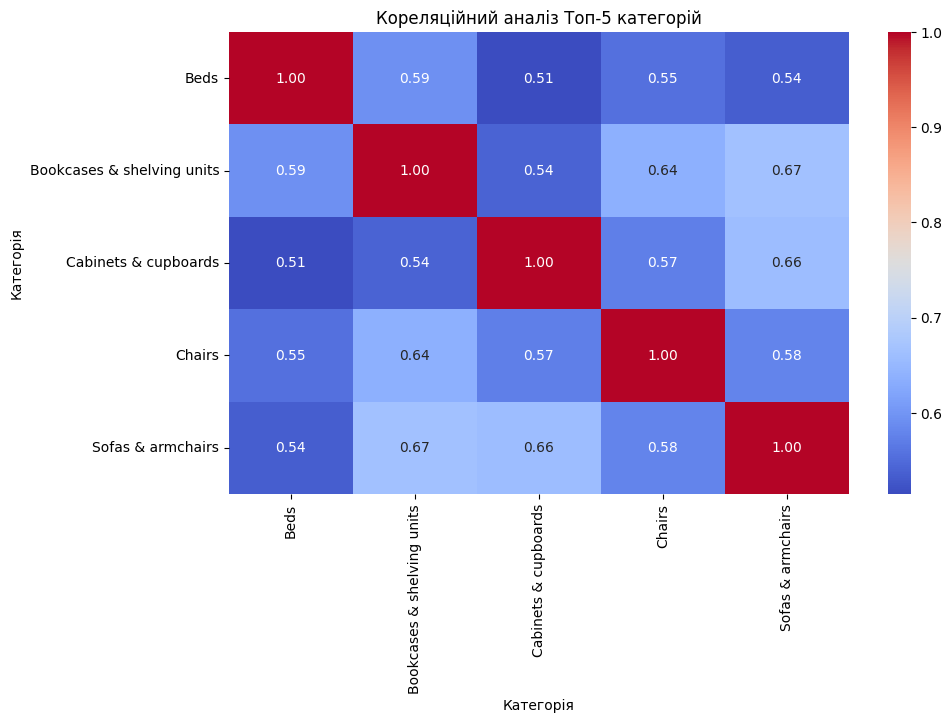

In [77]:
pivot_corr = daily_sales_by_categories.corr()

plt.figure(figsize=(10,6))
sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляційний аналіз Топ-5 категорій")
plt.xlabel('Категорія', fontsize=10)
plt.ylabel('Категорія', fontsize=10)
plt.show()

## 7.5 Чи корелюють між собою продажі на різних типах девайсів?

In [79]:
from scipy._lib.array_api_compat import device
pivot_device = pd.pivot_table(df, values='price', index='date', columns='device', aggfunc='sum')
pivot_device = pivot_device.fillna(0)

device_list = pivot_device.columns

print("-//- Кореляційний аналіз типів девайсів -//-")

results = []

for i in range(len(device_list)):
    for j in range(i + 1, len(device_list)):
        dev1 = device_list[i]
        dev2 = device_list[j]

        r, p = pearsonr(pivot_device[dev1], pivot_device[dev2])

        results.append([dev1, dev2, r, p])

results_df = pd.DataFrame(results, columns=['device_1', 'device_2', 'r', 'p'])
results_df

-//- Кореляційний аналіз типів девайсів -//-


,device_1,device_2,r,p
0,desktop,mobile,0.873201,7.719911e-30
1,desktop,tablet,0.601354,2.316806e-10
2,mobile,tablet,0.567394,3.693817e-09


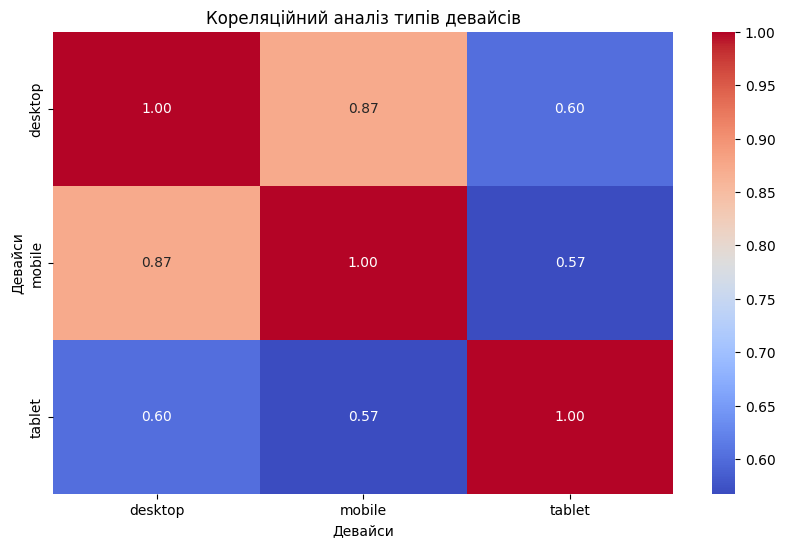

In [80]:
pivot_corr = pivot_device.corr()

plt.figure(figsize=(10,6))
sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляційний аналіз типів девайсів")
plt.xlabel('Девайси', fontsize=10)
plt.ylabel('Девайси', fontsize=10)
plt.show()

# **8. Статистичний аналіз відмінностей між групами**

## 8.1 Аналіз продажів за кожну дату зареєстрованих та незареєстрованих користувачів.

In [11]:
df_purchases = df.dropna(subset=['price'])

sample_registered = df_purchases[df_purchases['account_verified'] == 1]['price']
sample_unregistered = df_purchases[df_purchases['account_verified'] == 0]['price']

print(f"Кількість покупок (Зареєстровані): {len(sample_registered)}")
print(f"Кількість покупок (Незареєстровані): {len(sample_unregistered)}")

Кількість покупок (Зареєстровані): 1989
Кількість покупок (Незареєстровані): 792


Text(0, 0.5, 'Сума покупки')

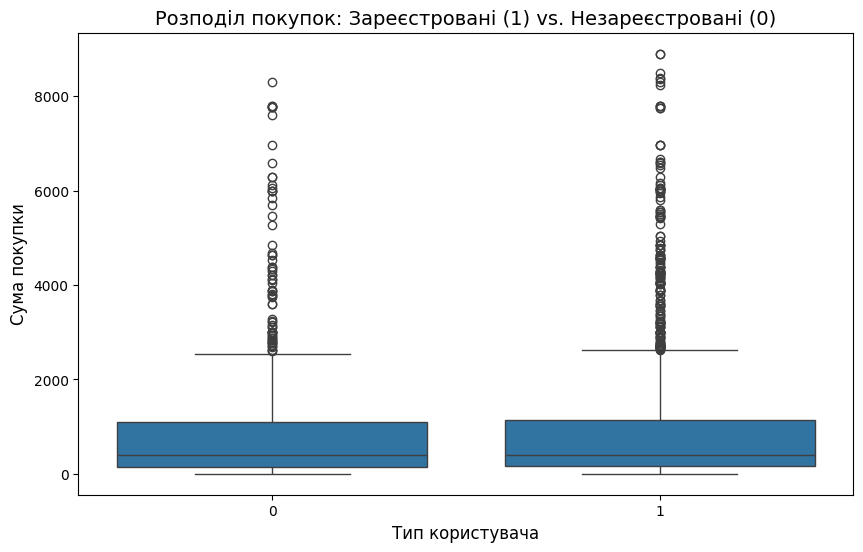

In [89]:
df_all_purchases = df_purchases[df_purchases['account_verified'].isin([0, 1])]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_purchases, x='account_verified', y='price')
plt.title('Розподіл покупок: Зареєстровані (1) vs. Незареєстровані (0)', fontsize=14)
plt.xlabel('Тип користувача', fontsize=12)
plt.ylabel('Сума покупки', fontsize=12)

In [13]:
shapiro_reg = shapiro(sample_registered.sample(min(len(sample_registered), 5000)))
shapiro_unreg = shapiro(sample_unregistered.sample(min(len(sample_unregistered), 5000)))

print(f"\nТест Шапіро (Зареєстровані) p-value: {shapiro_reg.pvalue}")
print(f"Тест Шапіро (Незареєстровані) p-value: {shapiro_unreg.pvalue}")

is_normal = (shapiro_reg.pvalue > 0.05) and (shapiro_unreg.pvalue > 0.05)
if is_normal:
    print("Висновок: Обидві вибірки виглядають нормально розподіленими.")
else:
    print("Висновок: Принаймні одна вибірка НЕ є нормально розподіленою (p < 0.05).")

if not is_normal:
    print("\n-//- Проводимо тест Манна-Вітні -//-")

    u_stat, p_value_mw = mannwhitneyu(sample_registered, sample_unregistered, alternative='two-sided')

    print(f"U-статистика: {u_stat}")
    print(f"P-value: {p_value_mw}")

    if p_value_mw < 0.05:
        print("Результат є статистично значущим (p < 0.05).")
        print("-> Існує значуща різниця у сумах покупок між групами.")
    else:
        print("Результат НЕ є статистично значущим (p >= 0.05).")
        print("-> Немає значущої різниці у сумах покупок між групами.")
else:
    print("\n Дані виглядають нормальними, можна було використати t-тест.")


Тест Шапіро (Зареєстровані) p-value: 2.8098573159514108e-52
Тест Шапіро (Незареєстровані) p-value: 3.342511484422477e-37
Висновок: Принаймні одна вибірка НЕ є нормально розподіленою (p < 0.05).

-//- Проводимо тест Манна-Вітні -//-
U-статистика: 808705.5
P-value: 0.27041393557910354
Результат НЕ є статистично значущим (p >= 0.05).
-> Немає значущої різниці у сумах покупок між групами.


## 8.2 Аналіз кількості сесій за різними каналами трафіку.

In [16]:
grouped_traffic_session = pd.pivot_table(df, values = 'session_id',index='date', columns = 'traffic_source_information',aggfunc = 'count')
grouped_traffic_session= grouped_traffic_session.fillna(0)
print(grouped_traffic_session.to_string())

traffic_list = grouped_traffic_session.columns

print("\n-//- Кореляційний аналіз каналів трафіку -//-")

results = []

for i in range(len(traffic_list)):
    for j in range(i + 1, len(traffic_list)):
        traffic1 = traffic_list[i]
        traffic2 = traffic_list[j]

        r, p = pearsonr(grouped_traffic_session[traffic1], grouped_traffic_session[traffic2])

        results.append([traffic1, traffic2, r, p])

results_df = pd.DataFrame(results, columns=['traffic_1', 'traffic_2', 'r', 'p'])
results_df

traffic_source_information  Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                                     
2020-11-01                     608             920          706            214        128
2020-11-02                     810            1242          970            315        262
2020-11-03                    1216            1871         1367            392        327
2020-11-04                     935            1425         1145            368        311
2020-11-05                     845            1293          917            346        342
2020-11-06                     744            1121          798            306        273
2020-11-07                     541             785          587            185        149
2020-11-08                     481             733          578            195        142
2020-11-09                     776            1077          827            268        231
2020-11-10

,traffic_1,traffic_2,r,p
0,Direct,Organic Search,0.983990,3.290596e-69
1,Direct,Paid Search,0.982272,3.113028e-67
2,Direct,Social Search,0.926936,4.380807e-40
3,Direct,Undefined,0.825833,4.109025e-24
4,Organic Search,Paid Search,0.986018,7.759894e-72
5,Organic Search,Social Search,0.907637,1.082372e-35
6,Organic Search,Undefined,0.797793,1.750457e-21
7,Paid Search,Social Search,0.904387,4.769689e-35
8,Paid Search,Undefined,0.789291,9.118828e-21
9,Social Search,Undefined,0.933451,7.569747e-42


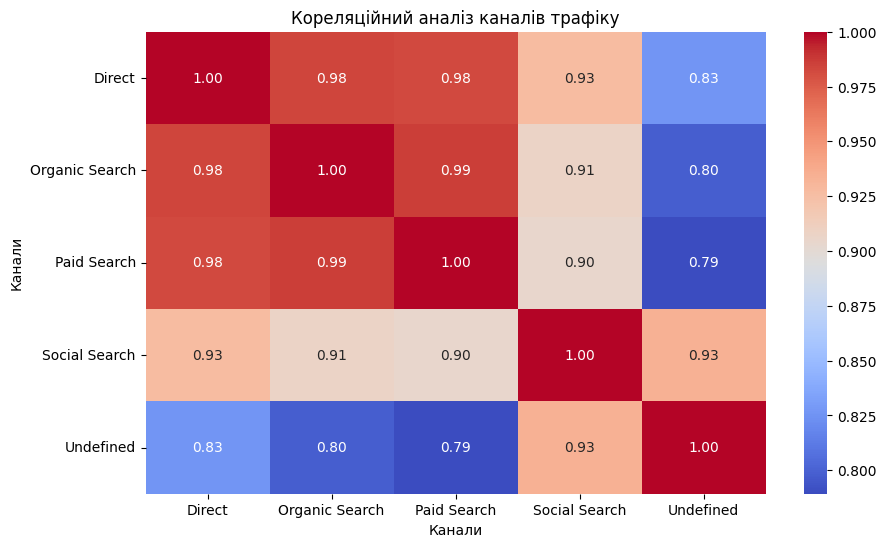

In [17]:
pivot_corr = grouped_traffic_session.corr()

plt.figure(figsize=(10,6))
sns.heatmap(pivot_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Кореляційний аналіз каналів трафіку")
plt.xlabel('Канали', fontsize=10)
plt.ylabel('Канали', fontsize=10)
plt.show()

## 8.3 Чи відрізняється статистично доля сесій з органічним трафіком у Європі та Америці?

In [18]:
america_europe = ['Americas', 'Europe']
america_europe_info = df[df['continent'].isin(america_europe)]

organic_sessions_europe = america_europe_info[(america_europe_info['continent'] == 'Europe') & (america_europe_info['traffic_source_information'] == 'Organic Search')].groupby('date')['session_id'].count()
organic_sessions_americas = america_europe_info[(america_europe_info['continent'] == 'Americas') & (america_europe_info['traffic_source_information'] == 'Organic Search')].groupby('date')['session_id'].count()

total_sessions_europe_daily = america_europe_info[america_europe_info['continent'] == 'Europe'].groupby('date')['session_id'].count()
total_sessions_americas_daily = america_europe_info[america_europe_info['continent'] == 'Americas'].groupby('date')['session_id'].count()

percent_organic_europe = (organic_sessions_europe / total_sessions_europe_daily).reindex(df['date'].unique(), fill_value=0)
percent_organic_americas = (organic_sessions_americas / total_sessions_americas_daily).reindex(df['date'].unique(), fill_value=0)

u_stat, p_value = mannwhitneyu(percent_organic_europe, percent_organic_americas, alternative='two-sided')

print("-//- Тест Манна-Вітні (Доля органічного трафіку) -//-")
print(f"Статистика U-тесту: {u_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Результат є статистично значущим (p < 0.05).")
    print("-> Існує значуща різниця в долі органічного трафіку між Європою та Америкою.")
else:
    print("Результат НЕ є статистично значущим (p >= 0.05).")
    print("-> Немає суттєвої різниці в долі органічного трафіку між Європою та Америкою.")

-//- Тест Манна-Вітні (Доля органічного трафіку) -//-
Статистика U-тесту: 4288.0
P-value: 0.877891970934652
Результат НЕ є статистично значущим (p >= 0.05).
-> Немає суттєвої різниці в долі органічного трафіку між Європою та Америкою.


## 8.4 Порівняння середніх продажів між усіма 5 каналами трафіку одночасно

In [24]:
grouped_traffic_session = pd.pivot_table(df, values='session_id', index='date', columns='traffic_source_information', aggfunc='count')
grouped_traffic_session = grouped_traffic_session.fillna(0)

sample_direct = grouped_traffic_session['Direct']
sample_organic = grouped_traffic_session['Organic Search']
sample_paid = grouped_traffic_session['Paid Search']
sample_social = grouped_traffic_session['Social Search']
sample_undefined = grouped_traffic_session['Undefined']

f_statistic, p_value = f_oneway(sample_direct, sample_organic, sample_paid, sample_social, sample_undefined)

print("-//- Тест ANOVA (F-тест) для 5 каналів трафіку -//-")
print(f"F-статистика: {f_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Результат є статистично значущим (p < 0.05).")
    print("-> Існує значуща різниця в середній кількості сесій між двома каналами.")
else:
    print("Результат НЕ є статистично значущим (p >= 0.05).")
    print("-> Немає суттєвої різниці в середній кількості сесій між каналами.")

-//- Тест ANOVA (F-тест) для 5 каналів трафіку -//-
F-статистика: 439.7675316990713
P-value: 8.433830529447116e-155
Результат є статистично значущим (p < 0.05).
-> Існує значуща різниця в середній кількості сесій між двома каналами.


**Висновки**

Проведенний статистичний аналіз показав, що:
* Відмінності між групами зареєстрованих та незареєстрованих користувачів на є статистично значущими
* Канали трафіку демонструють сильну синхронну динаміку
* Регіональні відмінності у структурі трафіку відсутні

# **9. Аналітичний дашборд у Tableau Public**

Посилання на [дашборд:](https://public.tableau.com/views/E-commercePerformanceDashboard_17780761009860/E-commercePerformanceDashboard?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)